# Experiment: CV HW1 Collaborative Scaffold

Objective:
- Complete homework Step 1-4 and the MLP part of Step 5 in a reusable way.
- Leave shared training and evaluation hooks so teammates can continue with CNN, ResNet, and ViT.


## Collaboration Notes

- Keep shared logic in `hw1_framework.py` so notebook cells stay short and easy to merge.
- Use the `RUN_*` flags before launching long experiments.
- Teammates should reuse the shared data split and training wrapper instead of writing separate loops.


In [7]:
# Core notebook imports.
from pathlib import Path
import copy

import pandas as pd

import hw1_framework as hw


In [8]:
# Resolve the project root and create shared output folders.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "CV_HW1":
    PROJECT_DIR = Path("/home/ykshi/cv/CV_Group8_HW1")

project_paths = hw.ensure_project_dirs(PROJECT_DIR)
runtime_config = hw.get_default_runtime_config(PROJECT_DIR)

# Fix the seed once so everyone uses the same dataset split and training randomness.
hw.set_seed(runtime_config["seed"])
device = hw.get_device()

print(f"Project directory: {PROJECT_DIR}")
print(f"Device: {device}")
print(f"Output folders: {project_paths}")


Project directory: /home/ykshi/cv/CV_Group8_HW1
Device: cuda
Output folders: {'root': PosixPath('/home/ykshi/cv/CV_Group8_HW1'), 'data': PosixPath('/home/ykshi/cv/CV_Group8_HW1/data'), 'figures': PosixPath('/home/ykshi/cv/CV_Group8_HW1/figures'), 'models': PosixPath('/home/ykshi/cv/CV_Group8_HW1/models'), 'results': PosixPath('/home/ykshi/cv/CV_Group8_HW1/results')}


## Step 1-4: Data Loading, Split, And Visualization

This section covers the reusable part of the homework that all four models share.


In [9]:
# Load EMNIST Balanced with one fixed train/validation/test setup.
loaders = hw.load_emnist_balanced(
    data_dir=runtime_config["data_dir"],
    batch_size=runtime_config["batch_size"],
    valid_ratio=runtime_config["valid_ratio"],
    num_workers=runtime_config["num_workers"],
    subset_ratio=1.0,
    augment=runtime_config["augment"],
    rotation_deg=runtime_config["rotation_deg"],
    noise_std=runtime_config["noise_std"],
    blur=runtime_config["blur"],
    seed=runtime_config["seed"],
)

class_names = loaders["class_names"]
dataset_stats = hw.show_dataset_stats(
    loaders["train_dataset"],
    loaders["valid_dataset"],
    loaders["test_dataset"],
    class_names,
)
dataset_stats


  split  samples
  train   101520
  valid    11280
   test    18800
classes       47


,split,samples
0,train,101520
1,valid,11280
2,test,18800
3,classes,47


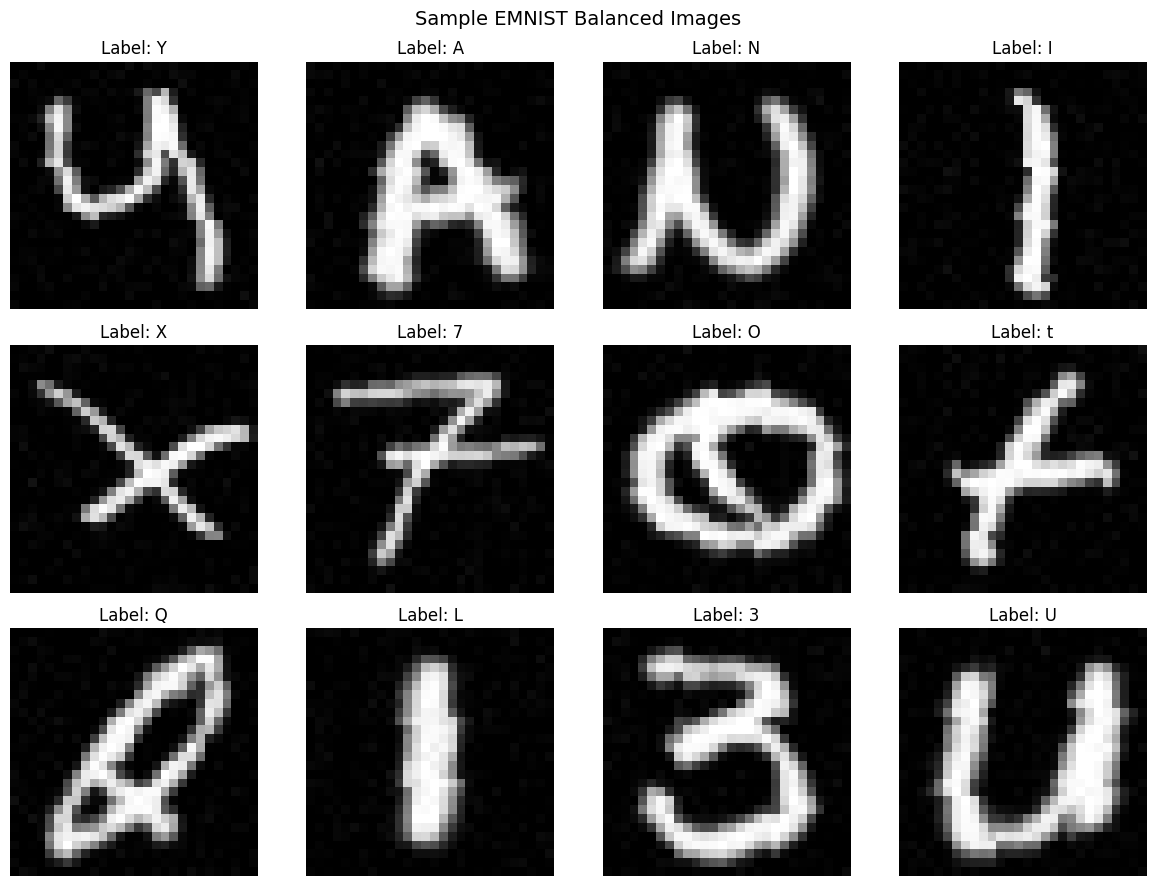

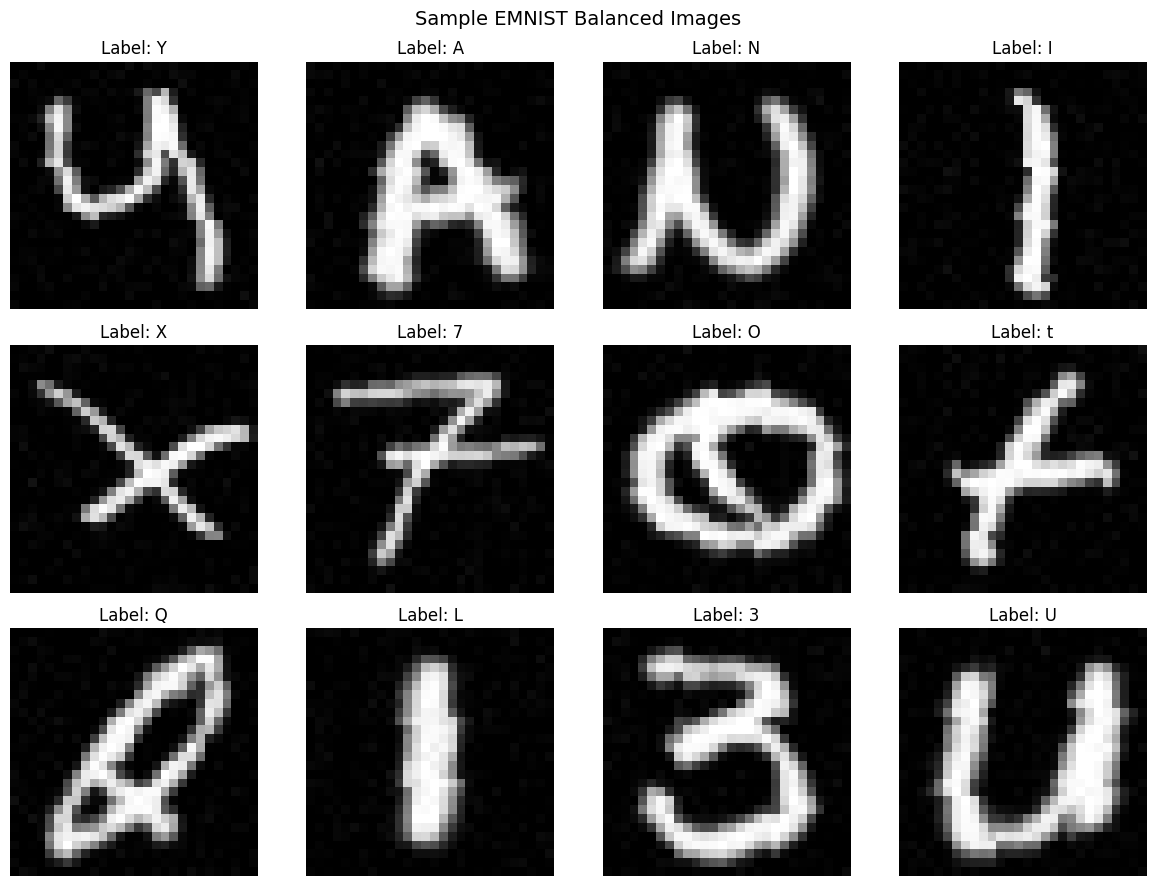

In [10]:
# Plot a few samples so the team can verify label coverage and image orientation early.
sample_figure = hw.show_sample_images(
    dataset=loaders["train_dataset"],
    class_names=class_names,
    num_samples=12,
    seed=runtime_config["seed"],
)
sample_figure


## MLP Baseline And Search Plan

The workflow below is the template that the other three model owners can reuse later.


In [5]:
# Start from one stable baseline, then replace one factor at a time.
mlp_config = hw.get_default_mlp_config()
mlp_search_plan = {
    "scheduler": ["StepLR", "CosineAnnealingLR", "ReduceLROnPlateau"],
    "activation": ["relu", "leaky_relu", "gelu"],
    "optimizer": ["adam", "sgd", "rmsprop"],
    "normalization": ["batchnorm", "layernorm", "none"],
    "dropout": [0.0, 0.3, 0.5],
}

# L1 and L2 change two fields together, so they are tracked separately from the single-factor loop.
mlp_regularization_trials = [
    {"name": "no_regularization", "l1_lambda": 0.0, "weight_decay": 0.0},
    {"name": "l1_regularization", "l1_lambda": 1e-6, "weight_decay": 0.0},
    {"name": "l2_regularization", "l1_lambda": 0.0, "weight_decay": 1e-4},
]

pd.Series(mlp_config, name="baseline_value")


input_dim                                             784
hidden_dims                               [512, 256, 128]
num_classes                                            47
activation                                           relu
normalization                                   batchnorm
dropout                                               0.3
optimizer                                            adam
learning_rate                                       0.001
scheduler                                          StepLR
scheduler_params           {'step_size': 5, 'gamma': 0.5}
weight_decay                                       0.0001
l1_lambda                                             0.0
epochs                                                 12
early_stopping_patience                                 4
Name: baseline_value, dtype: object

In [6]:
# Preview the MLP structure before training and record its parameter count for the report.
mlp_preview = hw.build_mlp(mlp_config)
print(mlp_preview)
print(f"Trainable parameters: {hw.count_parameters(mlp_preview):,}")


MLPClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.3, inplace=False)
    (13): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable parameters: 573,999


In [7]:
# Keep heavy retraining opt-in. The saved baseline result is shown in the snapshot section below.
RUN_MLP_BASELINE = False

if RUN_MLP_BASELINE:
    mlp_baseline_result = hw.run_training_experiment(
        model_name="mlp_baseline",
        model_builder=hw.build_mlp,
        config=mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_baseline_curves = hw.plot_training_curves(
        mlp_baseline_result["history"],
        "MLP Baseline",
    )
    mlp_baseline_summary = pd.DataFrame([mlp_baseline_result["summary"]])
    mlp_baseline_summary
else:
    print("已跳过重新训练 MLP baseline；下方结果快照会直接展示已保存结果。")


已跳过重新训练 MLP baseline；下方结果快照会直接展示已保存结果。


In [8]:
# Sequential search remains opt-in because it is time-consuming.
RUN_MLP_SEARCH = False

if RUN_MLP_SEARCH:
    search_tables = []
    tuned_mlp_config = copy.deepcopy(mlp_config)

    for factor_name, candidate_values in mlp_search_plan.items():
        factor_result = hw.run_single_factor_search(
            model_name="mlp",
            model_builder=hw.build_mlp,
            base_config=tuned_mlp_config,
            factor_name=factor_name,
            candidate_values=candidate_values,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        search_tables.append(factor_result["results"])
        tuned_mlp_config = factor_result["best_config"]

    regularization_rows = []
    best_regularized_config = copy.deepcopy(tuned_mlp_config)
    best_regularization_score = float("-inf")
    for trial in mlp_regularization_trials:
        trial_config = copy.deepcopy(tuned_mlp_config)
        trial_config["l1_lambda"] = trial["l1_lambda"]
        trial_config["weight_decay"] = trial["weight_decay"]
        trial_result = hw.run_training_experiment(
            model_name=f"mlp_{trial['name']}",
            model_builder=hw.build_mlp,
            config=trial_config,
            loaders=loaders,
            device=device,
            output_dir=project_paths["models"] / "search",
        )
        regularization_rows.append(
            {
                "factor": "regularization",
                "candidate": trial["name"],
                "best_valid_accuracy": trial_result["summary"]["best_valid_accuracy"],
                "best_epoch": trial_result["summary"]["best_epoch"],
                "training_time_sec": trial_result["summary"]["training_time_sec"],
            }
        )
        if trial_result["summary"]["best_valid_accuracy"] > best_regularization_score:
            best_regularization_score = trial_result["summary"]["best_valid_accuracy"]
            best_regularized_config = trial_config

    tuned_mlp_config = best_regularized_config
    mlp_search_results = pd.concat(
        [*search_tables, pd.DataFrame(regularization_rows)],
        ignore_index=True,
    )
    mlp_search_results
else:
    tuned_mlp_config = copy.deepcopy(mlp_config)
    print("已跳过重新运行 MLP 调参搜索；下方结果快照会展示已保存搜索结果。")


已跳过重新运行 MLP 调参搜索；下方结果快照会展示已保存搜索结果。


In [9]:
# Final training stays optional because the saved final checkpoint and metrics already exist.
RUN_MLP_FINAL = False

if RUN_MLP_FINAL:
    mlp_final_result = hw.run_training_experiment(
        model_name="mlp_best",
        model_builder=hw.build_mlp,
        config=tuned_mlp_config,
        loaders=loaders,
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_final_curves = hw.plot_training_curves(
        mlp_final_result["history"],
        "MLP Best Model",
    )
    mlp_test_metrics = hw.evaluate_on_test(
        mlp_final_result["model"],
        loaders["test_loader"],
        device,
    )
    mlp_metric_table = pd.DataFrame([hw.summarize_metrics(mlp_test_metrics)])
    mlp_metric_table
else:
    print("已跳过重新训练最终 MLP；下方结果快照会展示最终指标和曲线图。")


已跳过重新训练最终 MLP；下方结果快照会展示最终指标和曲线图。


In [10]:
# Re-render the visualizations only when you really need to regenerate them.
if "mlp_final_result" in globals():
    prediction_figure = hw.preview_predictions(
        model=mlp_final_result["model"],
        loader=loaders["test_loader"],
        class_names=class_names,
        device=device,
        num_samples=6,
    )
    confusion_figure = hw.plot_confusion_matrix_from_preds(
        y_true=mlp_test_metrics["y_true"],
        y_pred=mlp_test_metrics["y_pred"],
        class_names=class_names,
        model_name="MLP",
    )
    prediction_figure
    confusion_figure
else:
    print("已完成的预测样例和混淆矩阵会在下方结果快照中直接显示。")


已完成的预测样例和混淆矩阵会在下方结果快照中直接显示。


In [11]:
# The saved small-sample comparison is shown below by default.
RUN_MLP_SMALL_SAMPLE = False

if RUN_MLP_SMALL_SAMPLE:
    mlp_small_sample_df, mlp_small_sample_runs = hw.run_small_sample_experiment(
        model_name="mlp",
        model_builder=hw.build_mlp,
        base_config=tuned_mlp_config,
        runtime_config=runtime_config,
        sample_ratios=[0.3, 0.5, 1.0],
        device=device,
        output_dir=project_paths["models"],
    )
    mlp_small_sample_df
else:
    print("已跳过重新运行小样本实验；下方结果快照会展示已保存的小样本结果。")


已跳过重新运行小样本实验；下方结果快照会展示已保存的小样本结果。


## 已完成结果快照

以下内容直接读取 `results/`、`figures/` 和 `models/` 中已保存的结果。其他同学打开 notebook 后，无需重新训练即可查看你已完成部分的完整输出。

### 1. 已完成步骤状态

,步骤,状态,说明
0,Step 1-4 数据加载、划分、可视化,已完成,数据统计和样本图像见上方单元
1,MLP baseline,已完成,已完成训练并保存 checkpoint
2,MLP 调参搜索,已完成,已完成 scheduler/activation/optimizer/normalizati...
3,MLP 最终模型,已完成,已完成最终训练、测试评估与图像保存
4,MLP 小样本实验,已完成,已完成 30% / 50% / 100% 对比


### 2. 数据集划分结果

,split,samples,classes
0,train,101520,47
1,valid,11280,47
2,test,18800,47


### 3. Baseline 与最终模型指标对比

...

,search_name,candidate,best_valid_accuracy,best_valid_loss,best_epoch,training_time_sec,selected
5,activation,gelu,0.8409,0.4761,8,143.4583,True
4,activation,leaky_relu,0.8360,0.4873,8,144.1985,False
3,activation,relu,0.8326,0.4912,8,144.3085,False
12,dropout,dropout_0.0,0.8605,0.4018,8,136.4010,True
13,dropout,dropout_0.3,0.8432,0.4720,8,141.1737,False
14,dropout,dropout_0.5,0.8057,0.5760,8,142.6361,False
9,normalization,batchnorm,0.8391,0.4731,8,140.4264,True
11,normalization,none,0.8281,0.5085,8,138.8103,False
10,normalization,layernorm,0.8275,0.5162,8,140.7383,False
7,optimizer,sgd_5e-2,0.8413,0.4679,8,141.0680,True


### 6. 小样本实验结果

,sample_ratio,train_samples,best_valid_accuracy,test_accuracy,test_f1_macro
0,0.3,30456,0.8598,0.8601,0.8583
1,0.5,50760,0.8690,0.8709,0.8699
2,1.0,101520,0.8819,0.8795,0.8783


### 7. 关键图形结果

#### 训练/验证曲线

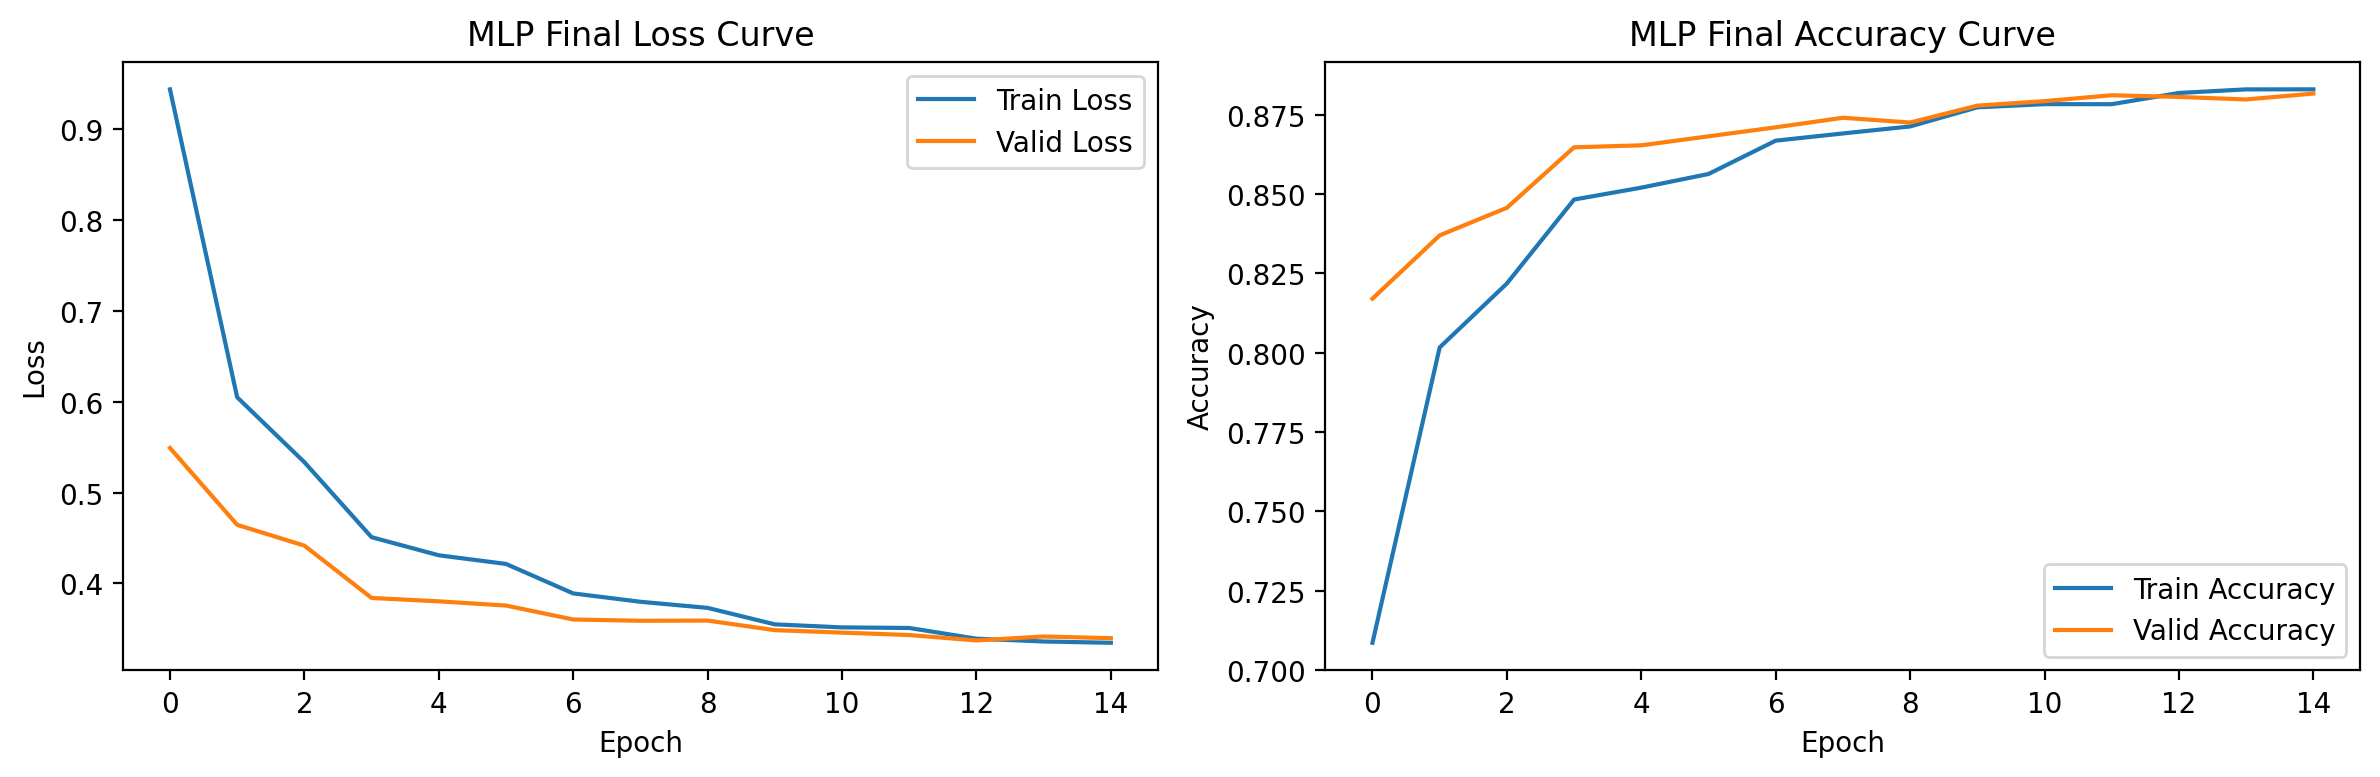

#### 前 6 个测试样本预测

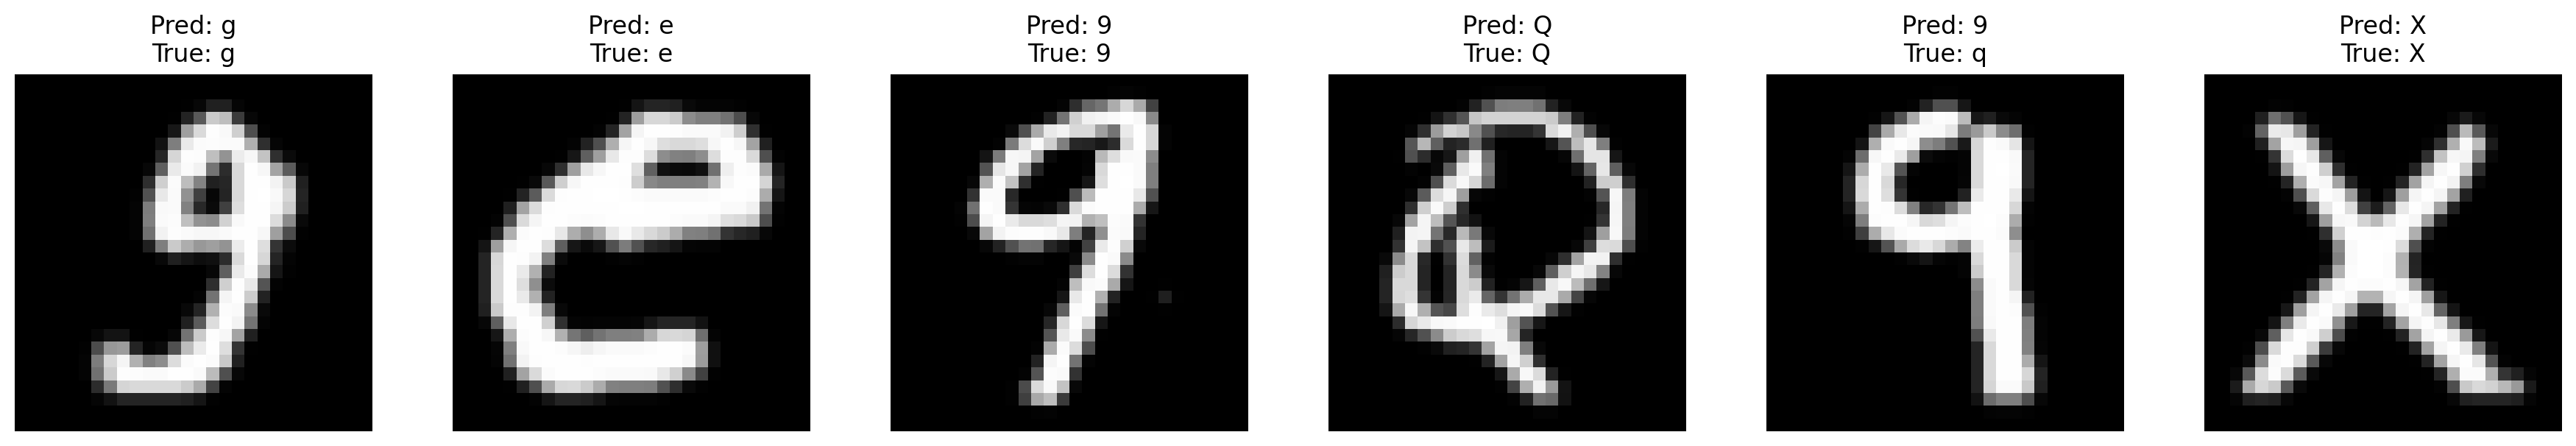

#### 测试集混淆矩阵

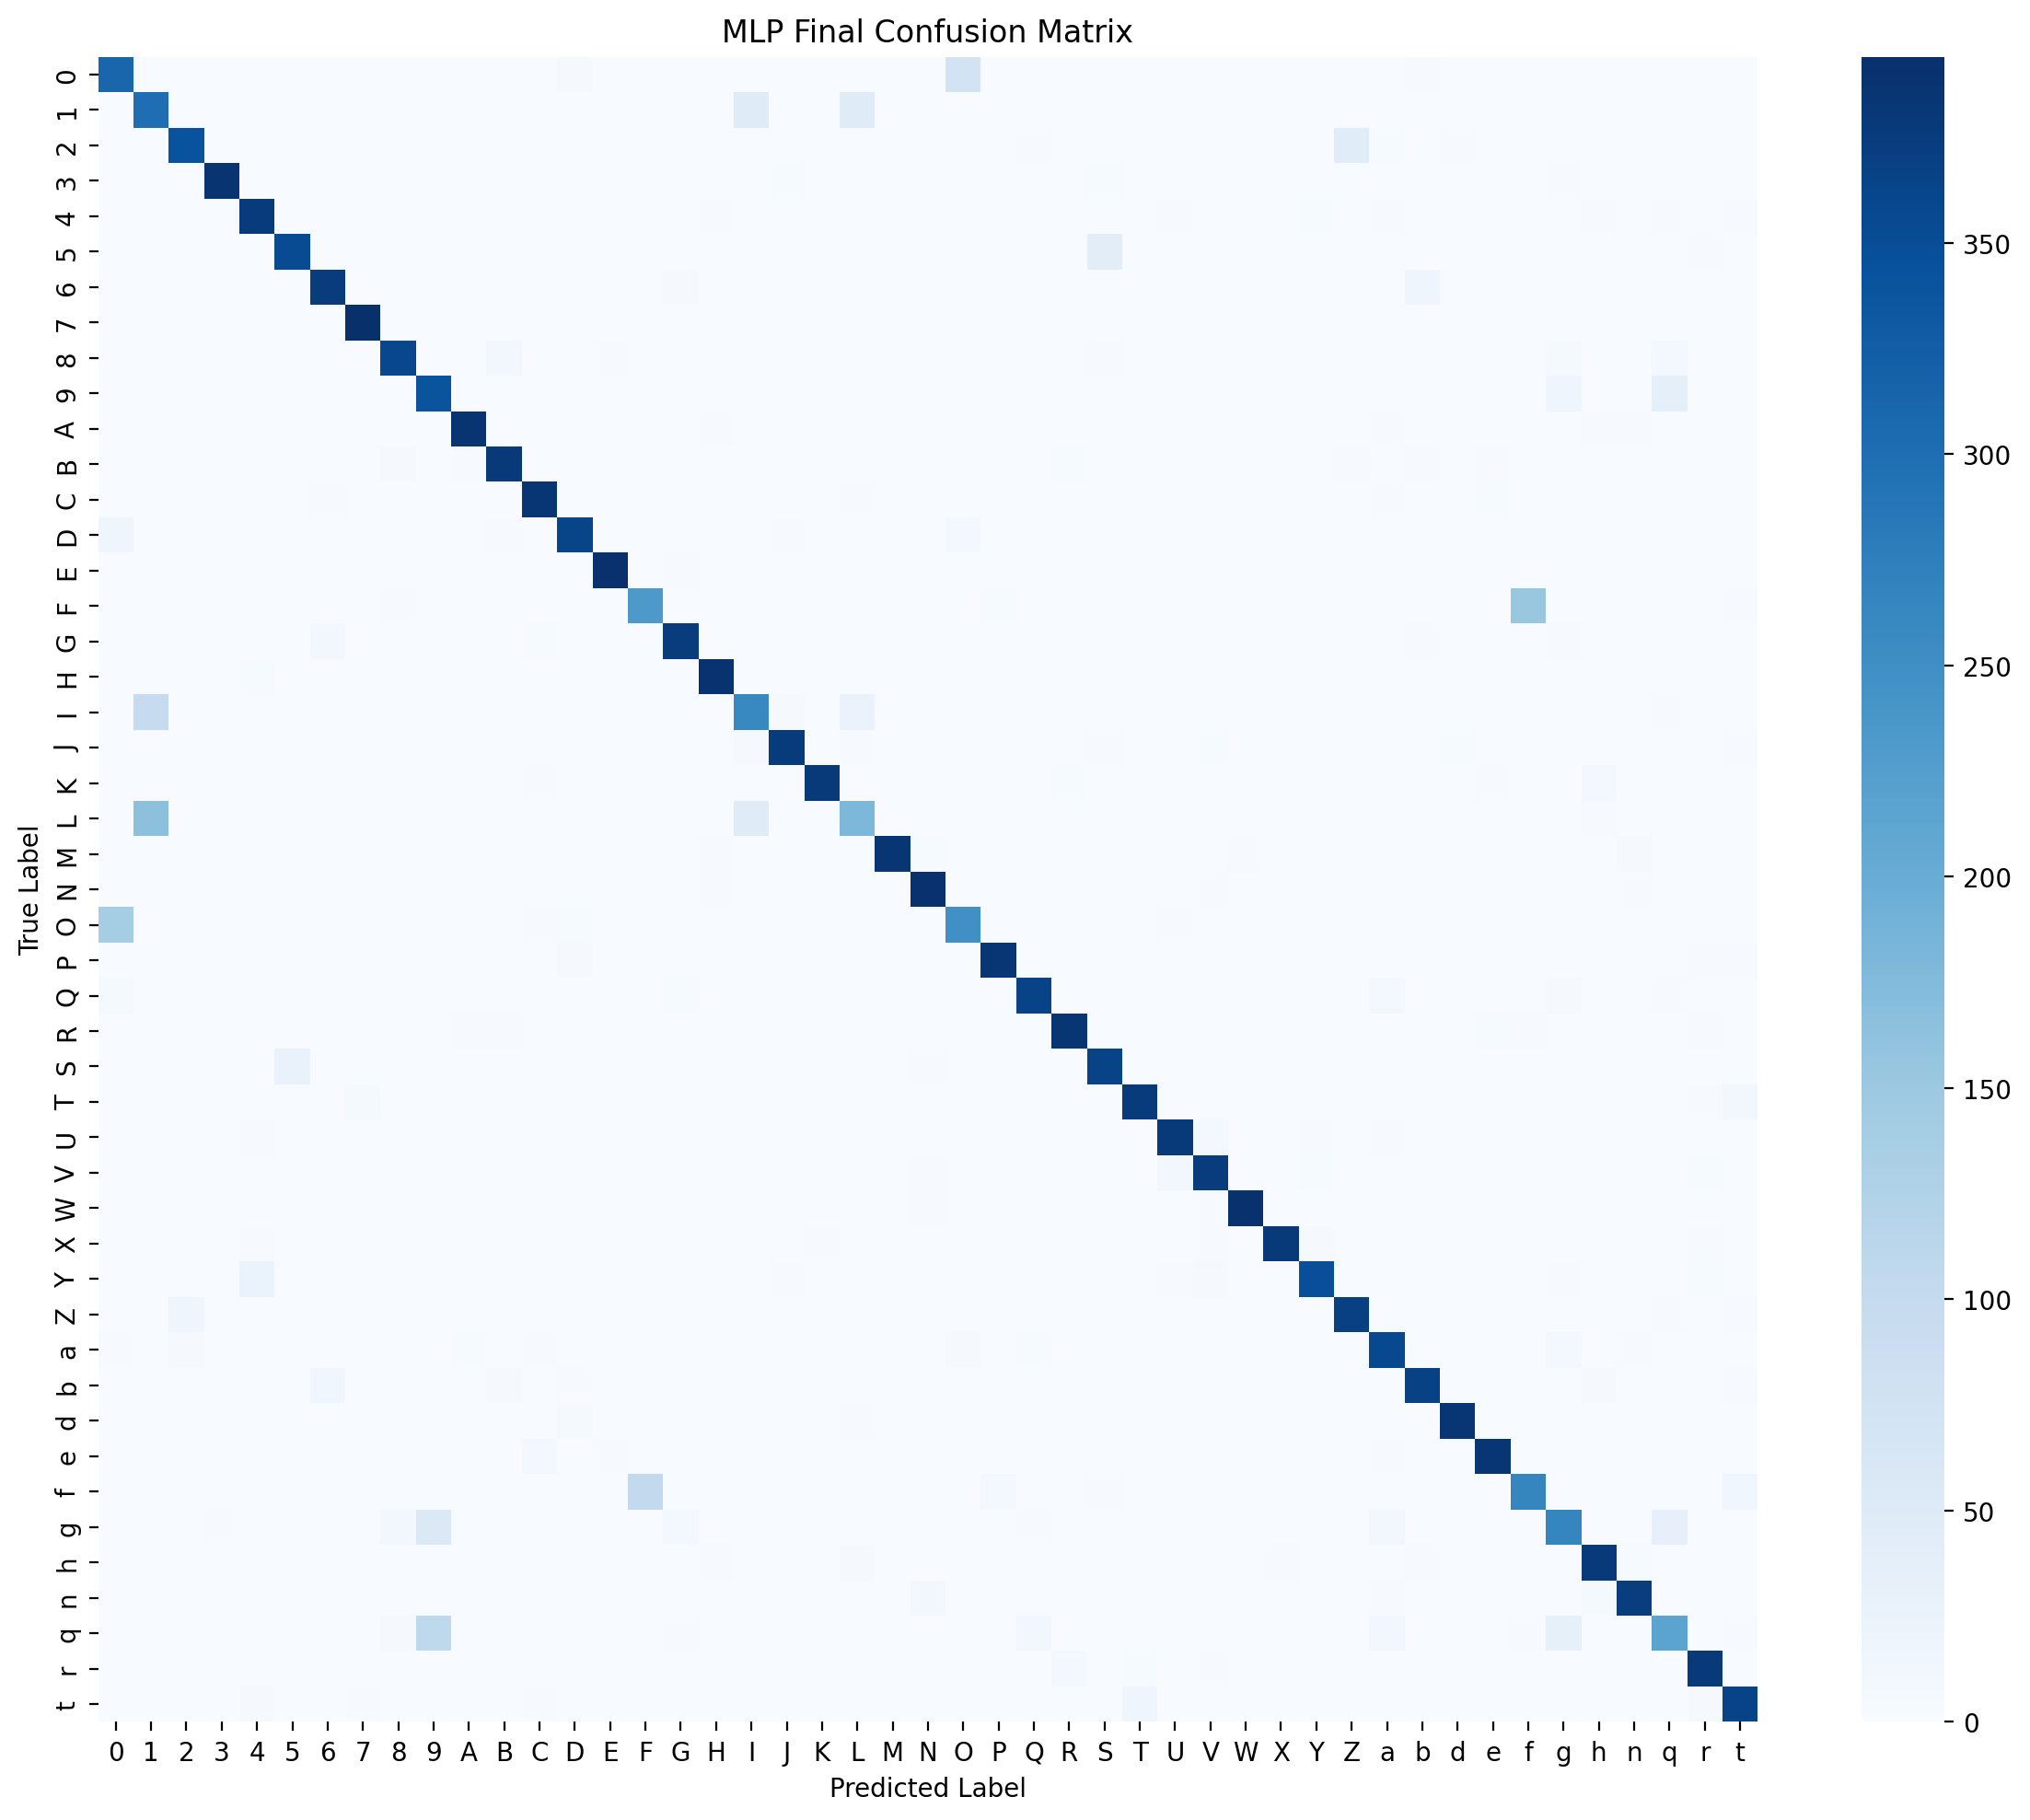

#### 30% / 50% / 100% 小样本对比

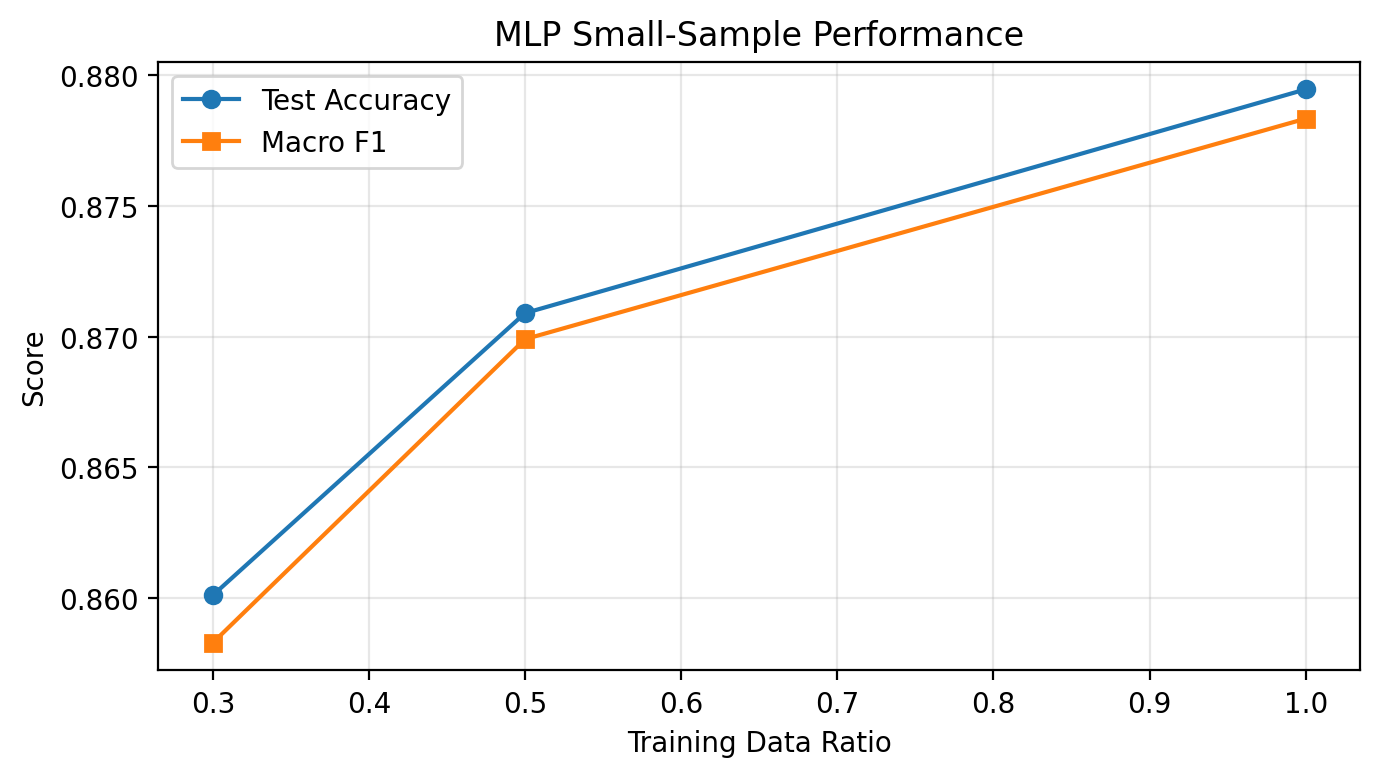

### 8. 已保存的重要产物

,产物,路径,存在
0,最终配置,D:\PythonProjects\CV_HW1\results\mlp_best_conf...,True
1,指标汇总,D:\PythonProjects\CV_HW1\results\mlp_metric_su...,True
2,搜索结果,D:\PythonProjects\CV_HW1\results\mlp_search_re...,True
3,小样本结果,D:\PythonProjects\CV_HW1\results\mlp_small_sam...,True
4,实验总结,D:\PythonProjects\CV_HW1\results\mlp_experimen...,True
5,最终 checkpoint,D:\PythonProjects\CV_HW1\models\mlp_final_best.pt,True


In [12]:
# 直接加载并展示已保存结果，让组员打开 notebook 就能看到当前完成状态。
import json
from IPython.display import Image, Markdown, display

saved_summary_path = PROJECT_DIR / "results" / "mlp_experiment_summary.json"
saved_small_sample_path = PROJECT_DIR / "results" / "mlp_small_sample_results.csv"
saved_search_path = PROJECT_DIR / "results" / "mlp_search_results.csv"
saved_metric_path = PROJECT_DIR / "results" / "mlp_metric_summary.csv"

figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "mlp_final_curves.png",
    "前 6 个测试样本预测": PROJECT_DIR / "figures" / "mlp_final_predictions.png",
    "测试集混淆矩阵": PROJECT_DIR / "figures" / "mlp_final_confusion_matrix.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "mlp_small_sample.png",
}

if saved_summary_path.exists():
    with saved_summary_path.open("r", encoding="utf-8") as f:
        saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    completion_df = pd.DataFrame([
        {"步骤": "Step 1-4 数据加载、划分、可视化", "状态": "已完成", "说明": "数据统计和样本图像见上方单元"},
        {"步骤": "MLP baseline", "状态": "已完成", "说明": "已完成训练并保存 checkpoint"},
        {"步骤": "MLP 调参搜索", "状态": "已完成", "说明": "已完成 scheduler/activation/optimizer/normalization/dropout/regularization 搜索"},
        {"步骤": "MLP 最终模型", "状态": "已完成", "说明": "已完成最终训练、测试评估与图像保存"},
        {"步骤": "MLP 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 对比"},
    ])
    display(completion_df)

    display(Markdown("### 2. 数据集划分结果"))
    dataset_snapshot = pd.DataFrame([
        {"split": "train", "samples": len(loaders["train_dataset"]), "classes": len(class_names)},
        {"split": "valid", "samples": len(loaders["valid_dataset"]), "classes": len(class_names)},
        {"split": "test", "samples": len(loaders["test_dataset"]), "classes": len(class_names)},
    ])
    display(dataset_snapshot)

    display(Markdown("### 3. Baseline 与最终模型指标对比"))
    metric_table = pd.DataFrame([
        {"stage": "baseline_valid", **saved_summary["baseline_valid_metrics"]},
        {"stage": "baseline_test", **saved_summary["baseline_test_metrics"]},
        {"stage": "final_valid", **saved_summary["final_valid_metrics"]},
        {"stage": "final_test", **saved_summary["final_test_metrics"]},
    ])
    display(metric_table.round(4))

    improvement_table = pd.DataFrame([
        {
            "指标": "accuracy",
            "baseline_test": saved_summary["baseline_test_metrics"]["accuracy"],
            "final_test": saved_summary["final_test_metrics"]["accuracy"],
            "提升": saved_summary["final_test_metrics"]["accuracy"] - saved_summary["baseline_test_metrics"]["accuracy"],
        },
        {
            "指标": "f1_macro",
            "baseline_test": saved_summary["baseline_test_metrics"]["f1_macro"],
            "final_test": saved_summary["final_test_metrics"]["f1_macro"],
            "提升": saved_summary["final_test_metrics"]["f1_macro"] - saved_summary["baseline_test_metrics"]["f1_macro"],
        },
    ])
    display(improvement_table.round(4))

    display(Markdown("### 4. 最终 MLP 配置"))
    final_config_df = pd.json_normalize(saved_summary["final_config"])
    display(final_config_df)

    display(Markdown("### 5. 调参搜索结果"))
    search_df = pd.read_csv(saved_search_path)
    if "selected" not in search_df.columns:
        search_df["selected"] = False
        best_indices = search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
        search_df.loc[best_indices, "selected"] = True
    display(search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))

    display(Markdown("### 6. 小样本实验结果"))
    small_sample_df = pd.read_csv(saved_small_sample_path)
    display(small_sample_df.round(4))

    display(Markdown("### 7. 关键图形结果"))
    for title, image_path in figure_paths.items():
        if image_path.exists():
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))

    display(Markdown("### 8. 已保存的重要产物"))
    artifact_rows = []
    for name, file_path in {
        "最终配置": PROJECT_DIR / "results" / "mlp_best_config.json",
        "指标汇总": saved_metric_path,
        "搜索结果": saved_search_path,
        "小样本结果": saved_small_sample_path,
        "实验总结": saved_summary_path,
        "最终 checkpoint": PROJECT_DIR / "models" / "mlp_final_best.pt",
    }.items():
        artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
    display(pd.DataFrame(artifact_rows))
else:
    print("未找到已保存结果文件，请先运行 run_mlp_pipeline.py。")


## Scaffolds For The Other Three Models

These configs and builders are ready for the teammates who own CNN, ResNet, and ViT.


In [13]:
# Every teammate should start here and then tune only their own model-specific config.
cnn_config = hw.get_default_cnn_config()
resnet_config = hw.get_default_resnet_config()
vit_config = hw.get_default_vit_config()

scaffold_rows = []
for model_name, config in {
    "cnn": cnn_config,
    "resnet": resnet_config,
    "vit": vit_config,
}.items():
    model = hw.MODEL_BUILDERS[model_name](config)
    scaffold_rows.append(
        {
            "model": model_name,
            "trainable_parameters": hw.count_parameters(model),
            "config_ready": True,
        }
    )

pd.DataFrame(scaffold_rows)


D:\PythonProjects\CV_HW1\hw1_framework.py:595: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


,model,trainable_parameters,config_ready
0,cnn,99183,True
1,resnet,312847,True
2,vit,544943,True


## ViT 已完成结果快照

以下内容会直接读取 `results/`、`figures/` 和 `models/` 中已保存的 ViT 结果。若当前还没有 ViT baseline、调参、最终训练或小样本实验产物，本单元会给出缺失文件提示；预测样例和混淆矩阵建议在下方 Shared Step 6 Hook 中统一生成，以保证四个模型的对比公平。


### 1. 已完成步骤状态

,步骤,状态,说明
0,ViT baseline,已完成,已完成训练并保存 baseline checkpoint
1,ViT 调参搜索,已完成,已完成 architecture/scheduler/activation/optimize...
2,ViT 最终模型,已完成,已完成最终训练、验证/测试评估与 checkpoint 保存
3,ViT 增强策略对比,已完成,已完成带增强与不带增强的训练设置对比
4,ViT 小样本实验,已完成,已完成 30% / 50% / 100% 小样本对比
5,ViT 预测样例 / 混淆矩阵,待共享评估,建议在 Shared Step 6 Hook 中统一生成，保证四个模型公平对比


### 2. 数据集划分结果

,split,samples,classes
0,train,101520,47
1,valid,11280,47
2,test,18800,47


### 3. Baseline 与最终模型参数量

...

,search_name,candidate,best_valid_accuracy,best_valid_loss,best_epoch,training_time_sec,selected
7,activation,gelu,0.7911,0.6264,8,170.6646,True
6,activation,relu,0.7591,0.7441,8,174.6007,False
8,activation,elu,0.7486,0.7753,8,170.2756,False
2,architecture,patch4_embed160_depth6_heads5,0.7267,0.8844,8,170.1558,True
0,architecture,patch7_embed96_depth4_heads4,0.6674,1.1807,8,149.4618,False
1,architecture,patch4_embed128_depth4_heads4,0.6537,1.1476,8,153.6869,False
15,dropout,dropout_0.0,0.8305,0.4964,7,169.2659,True
16,dropout,dropout_0.1,0.8291,0.5016,8,170.0607,False
17,dropout,dropout_0.2,0.7713,0.6960,8,171.7117,False
13,normalization,batchnorm,0.8241,0.5085,8,178.7947,True


### 11. 小样本实验结果

,sample_ratio,train_samples,best_valid_accuracy,best_valid_loss,test_accuracy,test_f1_macro
0,0.3,30456,0.8535,0.4166,0.8537,0.8511
1,0.5,50760,0.8761,0.3508,0.8752,0.8741
2,1.0,101520,0.8934,0.2910,0.8966,0.8952


### 12. 关键图形结果

#### 训练/验证曲线

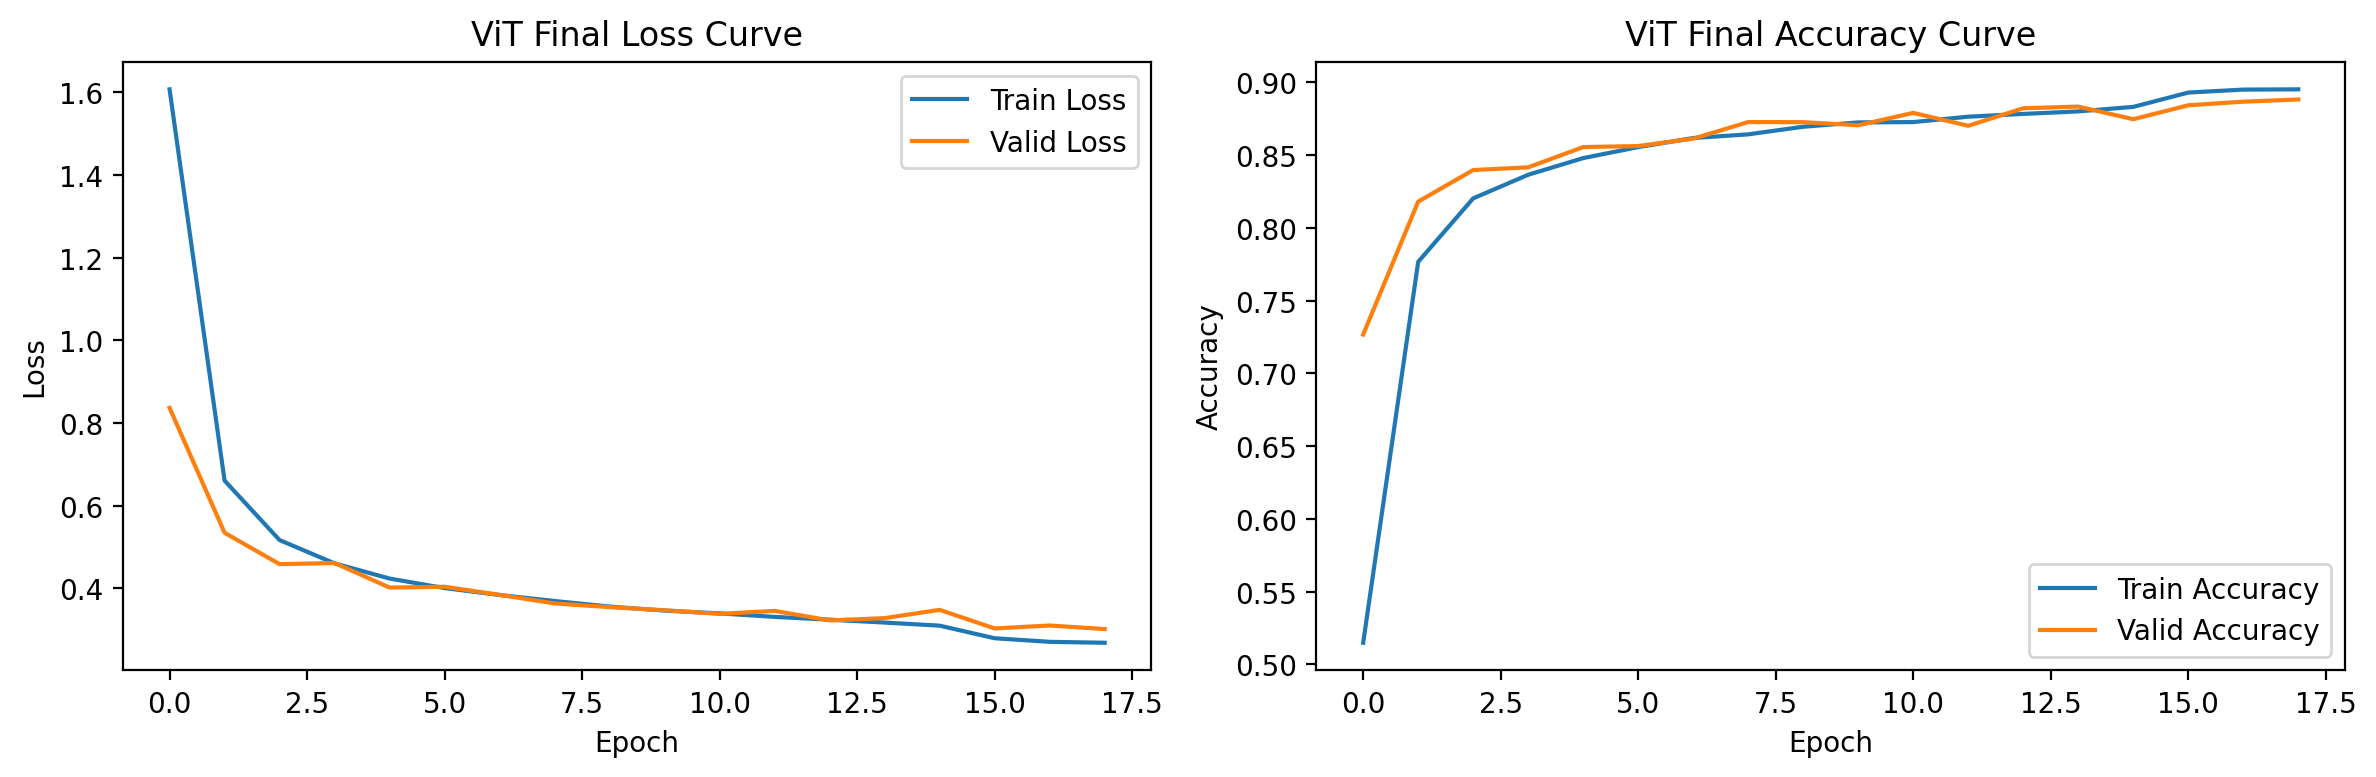

#### 增强策略对比

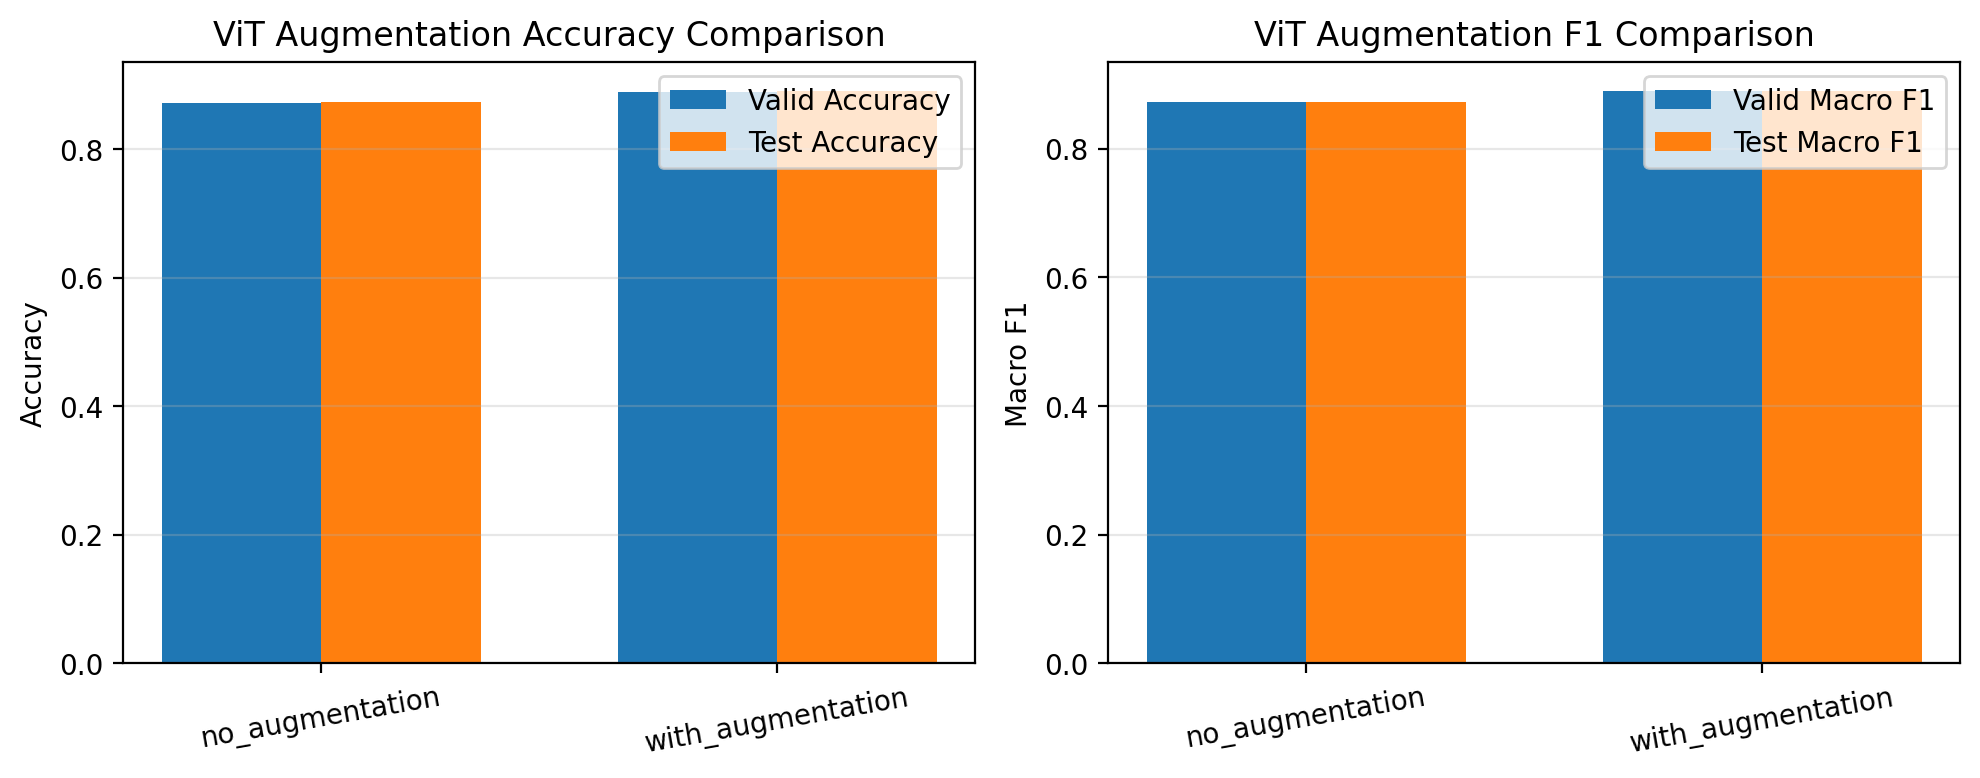

#### 30% / 50% / 100% 小样本对比

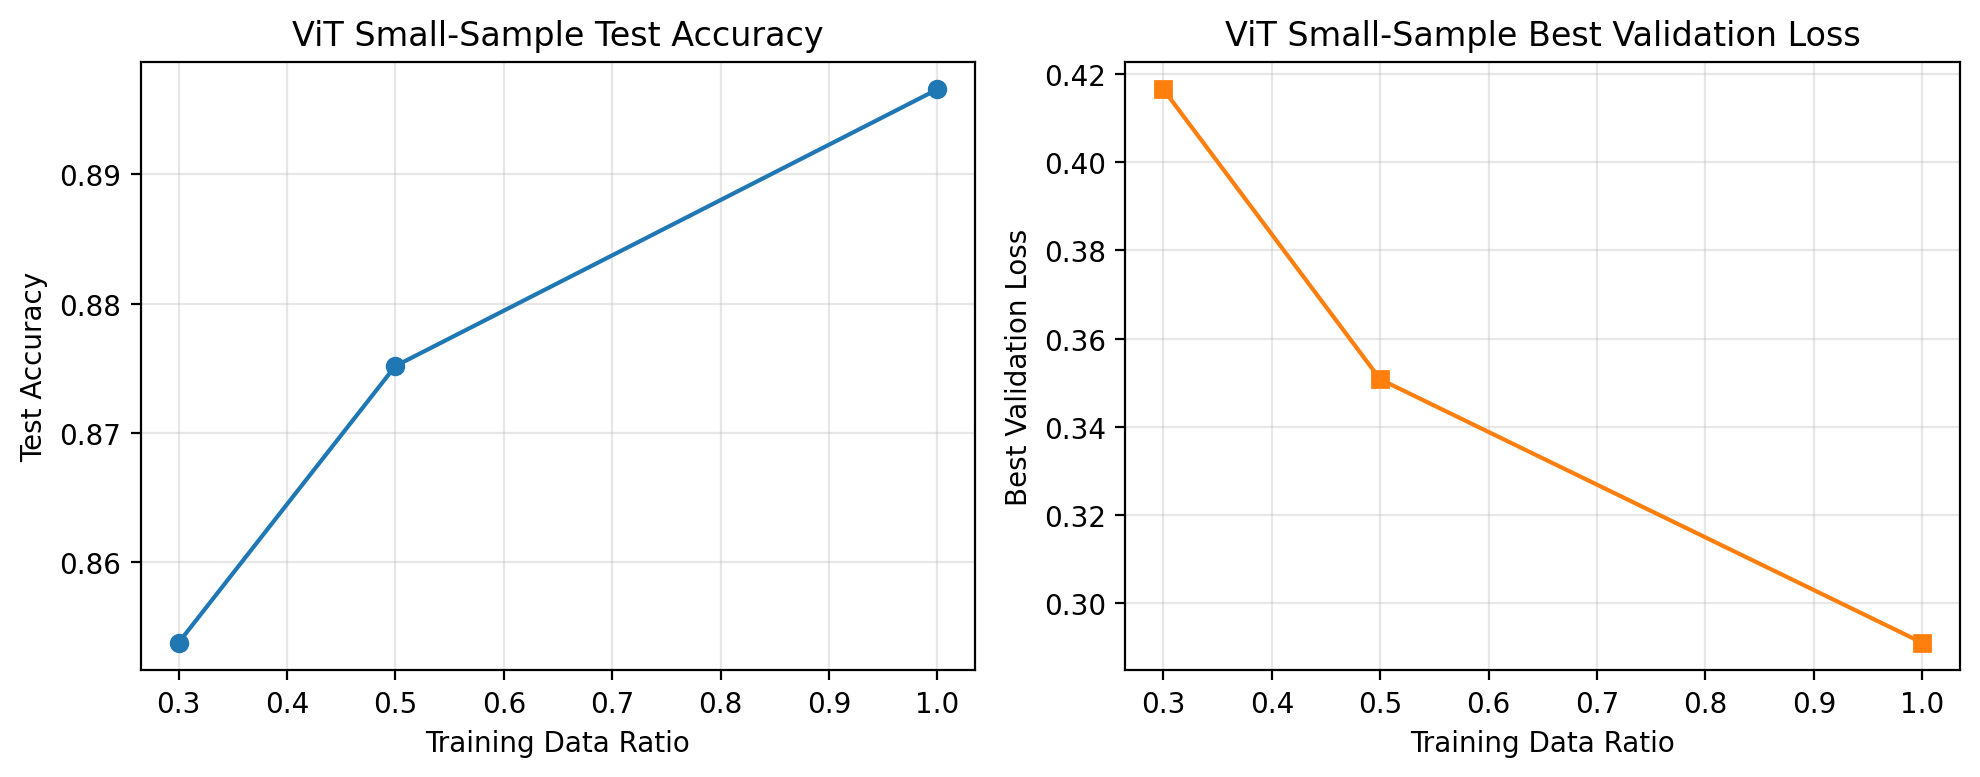

### 13. 已保存的重要产物

,产物,路径,存在
0,最终配置,/home/ykshi/cv/CV_Group8_HW1/results/vit_best_...,True
1,指标汇总,/home/ykshi/cv/CV_Group8_HW1/results/vit_metri...,True
2,增强对比,/home/ykshi/cv/CV_Group8_HW1/results/vit_augme...,True
3,搜索结果,/home/ykshi/cv/CV_Group8_HW1/results/vit_searc...,True
4,小样本结果,/home/ykshi/cv/CV_Group8_HW1/results/vit_small...,True
5,实验总结,/home/ykshi/cv/CV_Group8_HW1/results/vit_exper...,True
6,baseline checkpoint,/home/ykshi/cv/CV_Group8_HW1/models/vit_baseli...,True
7,最终 checkpoint,/home/ykshi/cv/CV_Group8_HW1/models/vit_final_...,True


In [11]:
# 直接加载并展示已保存的 ViT 结果，让组员打开 notebook 就能看到当前完成状态。
import json
from IPython.display import Image, Markdown, display

vit_saved_summary_path = PROJECT_DIR / "results" / "vit_experiment_summary.json"
vit_saved_small_sample_path = PROJECT_DIR / "results" / "vit_small_sample_results.csv"
vit_saved_search_path = PROJECT_DIR / "results" / "vit_search_results.csv"
vit_saved_metric_path = PROJECT_DIR / "results" / "vit_metric_summary.csv"
vit_saved_augmentation_path = PROJECT_DIR / "results" / "vit_augmentation_comparison.csv"

vit_figure_paths = {
    "训练/验证曲线": PROJECT_DIR / "figures" / "vit_final_curves.png",
    "增强策略对比": PROJECT_DIR / "figures" / "vit_augmentation_comparison.png",
    "30% / 50% / 100% 小样本对比": PROJECT_DIR / "figures" / "vit_small_sample.png",
}

vit_artifact_paths = {
    "最终配置": PROJECT_DIR / "results" / "vit_best_config.json",
    "指标汇总": vit_saved_metric_path,
    "增强对比": vit_saved_augmentation_path,
    "搜索结果": vit_saved_search_path,
    "小样本结果": vit_saved_small_sample_path,
    "实验总结": vit_saved_summary_path,
    "baseline checkpoint": PROJECT_DIR / "models" / "vit_baseline_best.pt",
    "最终 checkpoint": PROJECT_DIR / "models" / "vit_final_best.pt",
}

def vit_uniform_preprocessing_desc() -> str:
    return "方向修正（旋转 -90° + 水平翻转） -> ToTensor -> Normalize(mean=0.5, std=0.5)"

def vit_train_augmentation_desc(config_like) -> str:
    if not bool(config_like.get("augment", False)):
        return "无训练时随机增强"

    methods = []
    rotation_deg = float(config_like.get("rotation_deg", 0.0) or 0.0)
    noise_std = float(config_like.get("noise_std", 0.0) or 0.0)
    blur_enabled = bool(config_like.get("blur", False))

    if rotation_deg > 0:
        methods.append(f"RandomRotation({rotation_deg:g}°)")
    methods.append("RandomAffine(translate=0.05, scale=0.95-1.05)")
    methods.append(
        f"GaussianNoise(std={noise_std:g})" if noise_std > 0 else "GaussianNoise(未启用)"
    )
    methods.append(
        "GaussianBlur(kernel_size=3)" if blur_enabled else "GaussianBlur(未启用)"
    )
    return " + ".join(methods)

def vit_build_augmentation_method_table():
    if vit_saved_augmentation_path.exists():
        comparison_df = pd.read_csv(vit_saved_augmentation_path)
        rows = []
        for _, row in comparison_df.iterrows():
            row_dict = row.to_dict()
            rows.append(
                {
                    "设置": row_dict["setting"],
                    "是否被选为最终训练设置": "是" if bool(row_dict.get("selected_final", False)) else "否",
                    "统一预处理": vit_uniform_preprocessing_desc(),
                    "训练集增强方法": vit_train_augmentation_desc(row_dict),
                    "验证/测试处理": "仅统一预处理，不做随机增强",
                }
            )
        return pd.DataFrame(rows), comparison_df

    with_aug_runtime = dict(runtime_config)
    with_aug_runtime["augment"] = True
    no_aug_runtime = dict(runtime_config)
    no_aug_runtime.update({"augment": False, "rotation_deg": 0.0, "noise_std": 0.0, "blur": False})

    selected_setting = None
    if vit_saved_summary_path.exists():
        with vit_saved_summary_path.open("r", encoding="utf-8") as f:
            selected_setting = json.load(f).get("selected_training_setting")

    rows = []
    for setting_name, cfg in [
        ("no_augmentation", no_aug_runtime),
        ("with_augmentation", with_aug_runtime),
    ]:
        rows.append(
            {
                "设置": setting_name,
                "是否被选为最终训练设置": "是" if selected_setting == setting_name else "否" if selected_setting is not None else "未知",
                "统一预处理": vit_uniform_preprocessing_desc(),
                "训练集增强方法": vit_train_augmentation_desc(cfg),
                "验证/测试处理": "仅统一预处理，不做随机增强",
            }
        )
    return pd.DataFrame(rows), None

vit_augmentation_method_df, vit_augmentation_df = vit_build_augmentation_method_table()
vit_fairness_df = pd.DataFrame([
    {"公平性要求": "固定数据划分", "当前实现": f"使用同一个 seed={runtime_config['seed']} 划分 train/valid/test；验证集和测试集不随增强设置改变"},
    {"公平性要求": "训练数据量一致", "当前实现": "增强对比两组都使用 subset_ratio=1.0 的完整训练集"},
    {"公平性要求": "模型与超参数一致", "当前实现": "两组共用同一个 searched-best ViT 配置；不改变 architecture / optimizer / scheduler / epochs / early stopping"},
    {"公平性要求": "只改增强相关变量", "当前实现": "对比时仅切换 augment、rotation_deg、noise_std、blur 四项训练时增强参数"},
    {"公平性要求": "验证/测试不做随机增强", "当前实现": "valid/test 都走固定预处理：方向修正 + ToTensor + Normalize"},
    {"公平性要求": "统一选择标准", "当前实现": "两组都按 validation accuracy 选最佳模型，再汇报 test accuracy / test macro F1"},
])

if vit_saved_summary_path.exists():
    with vit_saved_summary_path.open("r", encoding="utf-8") as f:
        vit_saved_summary = json.load(f)

    display(Markdown("### 1. 已完成步骤状态"))
    vit_completion_df = pd.DataFrame([
        {"步骤": "ViT baseline", "状态": "已完成", "说明": "已完成训练并保存 baseline checkpoint"},
        {"步骤": "ViT 调参搜索", "状态": "已完成", "说明": "已完成 architecture/scheduler/activation/optimizer/normalization/dropout/regularization 搜索"},
        {"步骤": "ViT 最终模型", "状态": "已完成", "说明": "已完成最终训练、验证/测试评估与 checkpoint 保存"},
        {"步骤": "ViT 增强策略对比", "状态": "已完成", "说明": "已完成带增强与不带增强的训练设置对比"},
        {"步骤": "ViT 小样本实验", "状态": "已完成", "说明": "已完成 30% / 50% / 100% 小样本对比"},
        {"步骤": "ViT 预测样例 / 混淆矩阵", "状态": "待共享评估", "说明": "建议在 Shared Step 6 Hook 中统一生成，保证四个模型公平对比"},
    ])
    display(vit_completion_df)

    display(Markdown("### 2. 数据集划分结果"))
    vit_dataset_snapshot = pd.DataFrame([
        {"split": "train", "samples": len(loaders["train_dataset"]), "classes": len(class_names)},
        {"split": "valid", "samples": len(loaders["valid_dataset"]), "classes": len(class_names)},
        {"split": "test", "samples": len(loaders["test_dataset"]), "classes": len(class_names)},
    ])
    display(vit_dataset_snapshot)

    display(Markdown("### 3. Baseline 与最终模型参数量"))
    vit_parameter_table = pd.DataFrame([
        {"stage": "baseline", "trainable_parameters": vit_saved_summary["baseline_parameter_count"]},
        {"stage": "final", "trainable_parameters": vit_saved_summary["final_parameter_count"]},
    ])
    display(vit_parameter_table)

    display(Markdown("### 4. Baseline 与最终模型指标对比"))
    vit_metric_table = pd.DataFrame([
        {"stage": "baseline_valid", **vit_saved_summary["baseline_valid_metrics"]},
        {"stage": "baseline_test", **vit_saved_summary["baseline_test_metrics"]},
        {"stage": "final_valid", **vit_saved_summary["final_valid_metrics"]},
        {"stage": "final_test", **vit_saved_summary["final_test_metrics"]},
    ])
    display(vit_metric_table.round(4))

    vit_improvement_table = pd.DataFrame([
        {
            "指标": "accuracy",
            "baseline_test": vit_saved_summary["baseline_test_metrics"]["accuracy"],
            "final_test": vit_saved_summary["final_test_metrics"]["accuracy"],
            "提升": vit_saved_summary["final_test_metrics"]["accuracy"] - vit_saved_summary["baseline_test_metrics"]["accuracy"],
        },
        {
            "指标": "f1_macro",
            "baseline_test": vit_saved_summary["baseline_test_metrics"]["f1_macro"],
            "final_test": vit_saved_summary["final_test_metrics"]["f1_macro"],
            "提升": vit_saved_summary["final_test_metrics"]["f1_macro"] - vit_saved_summary["baseline_test_metrics"]["f1_macro"],
        },
    ])
    display(vit_improvement_table.round(4))

    display(Markdown("### 5. 最终 ViT 配置"))
    vit_final_config = vit_saved_summary["final_config"]
    vit_final_config_df = pd.json_normalize(vit_final_config)
    display(vit_final_config_df)

    display(Markdown("### 6. 最终训练设置"))
    display(pd.DataFrame([vit_saved_summary["final_runtime_config"]]))
    display(Markdown(f"- selected_training_setting: `{vit_saved_summary['selected_training_setting']}`"))

    display(Markdown("### 7. 增强方法说明"))
    display(vit_augmentation_method_df)
    display(Markdown("- `EmnistOrientationFix` 属于所有 split 统一共享的预处理，不作为本次增强对比的差异项。"))

    display(Markdown("### 8. 公平性说明"))
    display(vit_fairness_df)

    display(Markdown("### 9. 增强策略对比结果"))
    if vit_augmentation_df is not None:
        display(vit_augmentation_df.round(4))
    else:
        display(Markdown(f"未找到 `{vit_saved_augmentation_path.name}`。"))

    display(Markdown("### 10. 调参搜索结果"))
    if vit_saved_search_path.exists():
        vit_search_df = pd.read_csv(vit_saved_search_path)
        if "selected" not in vit_search_df.columns:
            vit_search_df["selected"] = False
            vit_best_indices = vit_search_df.groupby("search_name")["best_valid_accuracy"].idxmax()
            vit_search_df.loc[vit_best_indices, "selected"] = True
        display(vit_search_df.sort_values(["search_name", "best_valid_accuracy"], ascending=[True, False]).round(4))
    else:
        display(Markdown(f"未找到 `{vit_saved_search_path.name}`。"))

    display(Markdown("### 11. 小样本实验结果"))
    if vit_saved_small_sample_path.exists():
        vit_small_sample_df = pd.read_csv(vit_saved_small_sample_path)
        display(vit_small_sample_df.round(4))
    else:
        display(Markdown(f"未找到 `{vit_saved_small_sample_path.name}`。"))

    display(Markdown("### 12. 关键图形结果"))
    vit_has_figure = False
    for title, image_path in vit_figure_paths.items():
        if image_path.exists():
            vit_has_figure = True
            display(Markdown(f"#### {title}"))
            display(Image(filename=str(image_path)))
    if not vit_has_figure:
        display(Markdown("尚未找到已保存的 ViT 图像结果。"))
else:
    display(Markdown(
        "未找到已保存的 ViT 结果文件。\n\n"
        "如果要生成这一部分，请先运行 `run_vit_pipeline.py`；预测样例和混淆矩阵建议在下方 Shared Step 6 Hook 中统一生成。"
    ))
    display(Markdown("### 7. 增强方法说明"))
    display(vit_augmentation_method_df)
    display(Markdown("- `EmnistOrientationFix` 属于所有 split 统一共享的预处理，不作为本次增强对比的差异项。"))
    display(Markdown("### 8. 公平性说明"))
    display(vit_fairness_df)

display(Markdown("### 13. 已保存的重要产物"))
vit_artifact_rows = []
for name, file_path in vit_artifact_paths.items():
    vit_artifact_rows.append({"产物": name, "路径": str(file_path), "存在": file_path.exists()})
display(pd.DataFrame(vit_artifact_rows))


## Shared Step 6 Hook

Once all four best checkpoints are ready, use one shared evaluation cell to keep the comparison fair.


In [14]:
def evaluate_saved_models(best_model_paths, model_configs, shared_loaders, class_names, device):
    rows = []
    for model_name, checkpoint_path in best_model_paths.items():
        builder = hw.MODEL_BUILDERS[model_name]
        model = builder(model_configs[model_name]).to(device)
        hw.load_checkpoint(model, checkpoint_path, device)
        metrics = hw.evaluate_on_test(model, shared_loaders["test_loader"], device)
        rows.append({"model": model_name, **hw.summarize_metrics(metrics)})

        hw.preview_predictions(model, shared_loaders["test_loader"], class_names, device, num_samples=6)
        hw.plot_confusion_matrix_from_preds(
            metrics["y_true"],
            metrics["y_pred"],
            class_names,
            model_name.upper(),
        )

    return pd.DataFrame(rows)

# Example after all teammates finish their best models:
# best_model_paths = {
#     "mlp": project_paths["models"] / "mlp_final_best.pt",
#     "cnn": project_paths["models"] / "cnn_best.pt",
#     "resnet": project_paths["models"] / "resnet_best.pt",
#     "vit": project_paths["models"] / "vit_final_best.pt",
# }
# model_configs = {
#     "mlp": tuned_mlp_config,
#     "cnn": cnn_config,
#     "resnet": resnet_config,
#     "vit": vit_final_config,
# }
# final_report_df = evaluate_saved_models(best_model_paths, model_configs, loaders, class_names, device)


## Handoff Reminder

Read `README.md` before dividing work further. It records the file map, shared API, recommended ownership split, and the merge checklist.
